
# Deep Learning Chapter 21 Demonstrations  
## Backpropagation and CNN examples

This notebook is designed for **Google Colab** or a local Python environment.

## Local libraries needed

For a local run, install:

```bash
pip install numpy matplotlib
```

This notebook avoids heavyweight dependencies such as TensorFlow or PyTorch so that the core ideas remain visible.

## What this notebook covers

1. A small **feedforward neural network** trained with **manual backpropagation**
2. Visualization of **activation functions**
3. A simple **1D convolution** demonstration
4. A simple **2D convolution** on an image-like array
5. **Pooling** demonstrations
6. A tiny **CNN-style classifier pipeline** built from NumPy operations

The emphasis is pedagogical rather than performance-oriented.


In [1]:

import math
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)



## 1. Activation functions

Deep networks rely on nonlinear activation functions. Here we visualize the most common ones from the chapter:
- sigmoid
- tanh
- ReLU
- softplus


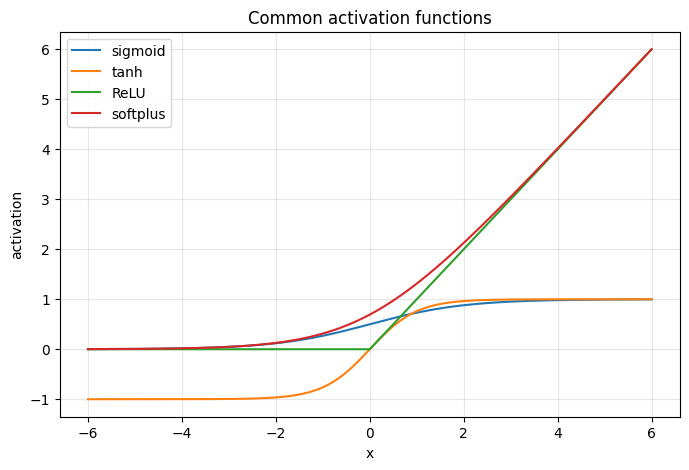

In [2]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def softplus(x):
    return np.log1p(np.exp(x))

x = np.linspace(-6, 6, 400)

plt.figure(figsize=(8, 5))
plt.plot(x, sigmoid(x), label="sigmoid")
plt.plot(x, tanh(x), label="tanh")
plt.plot(x, relu(x), label="ReLU")
plt.plot(x, softplus(x), label="softplus")
plt.title("Common activation functions")
plt.xlabel("x")
plt.ylabel("activation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 2. Manual backpropagation for a tiny neural network

We build a tiny network with:
- **2 inputs**
- **1 hidden layer with 2 neurons**
- **1 output neuron**

We train it on the XOR problem. This is a classic example because XOR is **not linearly separable**, so a single linear layer cannot solve it.


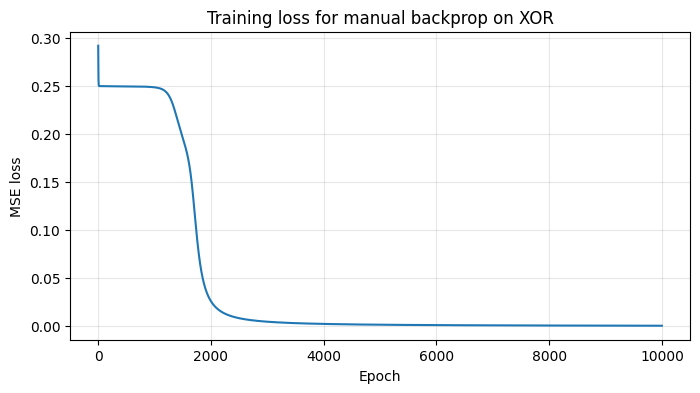

In [3]:

# XOR data
X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y = np.array([[0.0], [1.0], [1.0], [0.0]])

# Weight initialization
W1 = rng.normal(0, 1, size=(2, 2)) * 0.5
b1 = np.zeros((1, 2))
W2 = rng.normal(0, 1, size=(2, 1)) * 0.5
b2 = np.zeros((1, 1))

def sigmoid_derivative(a):
    # derivative in terms of output a = sigmoid(z)
    return a * (1 - a)

learning_rate = 1.0
epochs = 10000
loss_history = []

for epoch in range(epochs):
    # Forward pass
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    y_hat = sigmoid(z2)

    # Mean squared error
    loss = np.mean((y_hat - y) ** 2)
    loss_history.append(loss)

    # Backward pass
    dL_dyhat = 2 * (y_hat - y) / len(X)
    dL_dz2 = dL_dyhat * sigmoid_derivative(y_hat)

    dW2 = a1.T @ dL_dz2
    db2 = np.sum(dL_dz2, axis=0, keepdims=True)

    dL_da1 = dL_dz2 @ W2.T
    dL_dz1 = dL_da1 * sigmoid_derivative(a1)

    dW1 = X.T @ dL_dz1
    db1 = np.sum(dL_dz1, axis=0, keepdims=True)

    # Gradient descent update
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training loss for manual backprop on XOR")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.grid(True, alpha=0.3)
plt.show()


In [4]:

# Final predictions
z1 = X @ W1 + b1
a1 = sigmoid(z1)
z2 = a1 @ W2 + b2
y_hat = sigmoid(z2)

print("Predicted probabilities:")
print(y_hat)

print("\nPredicted classes:")
print((y_hat > 0.5).astype(int))

print("\nTrue classes:")
print(y.astype(int))


Predicted probabilities:
[[0.0235]
 [0.9734]
 [0.9737]
 [0.0213]]

Predicted classes:
[[0]
 [1]
 [1]
 [0]]

True classes:
[[0]
 [1]
 [1]
 [0]]



### What backpropagation is doing

For each layer, we:
1. compute the forward activations
2. compute the loss
3. propagate gradients backward using the chain rule
4. update the weights

The main pedagogical point is that **every weight is adjusted according to how much it contributed to the error**.



## 3. Inspecting one gradient step in detail

This cell prints the main intermediate values for one forward/backward pass, so students can connect the equations to actual arrays.


In [5]:

# Reinitialize smaller network for inspection
W1_demo = np.array([[0.4, -0.2],
                    [0.1,  0.3]])
b1_demo = np.array([[0.0, 0.0]])
W2_demo = np.array([[0.2],
                    [-0.5]])
b2_demo = np.array([[0.0]])

x_demo = np.array([[1.0, 0.0]])
y_demo = np.array([[1.0]])

z1 = x_demo @ W1_demo + b1_demo
a1 = sigmoid(z1)
z2 = a1 @ W2_demo + b2_demo
y_hat = sigmoid(z2)
loss = np.mean((y_hat - y_demo)**2)

dL_dyhat = 2 * (y_hat - y_demo)
dL_dz2 = dL_dyhat * sigmoid_derivative(y_hat)
dW2 = a1.T @ dL_dz2
db2 = np.sum(dL_dz2, axis=0, keepdims=True)
dL_da1 = dL_dz2 @ W2_demo.T
dL_dz1 = dL_da1 * sigmoid_derivative(a1)
dW1 = x_demo.T @ dL_dz1
db1 = np.sum(dL_dz1, axis=0, keepdims=True)

print("x_demo =\n", x_demo)
print("\nz1 =\n", z1)
print("\na1 =\n", a1)
print("\nz2 =\n", z2)
print("\ny_hat =\n", y_hat)
print("\nloss =\n", loss)

print("\ndW2 =\n", dW2)
print("\ndb2 =\n", db2)
print("\ndW1 =\n", dW1)
print("\ndb1 =\n", db1)


x_demo =
 [[1. 0.]]

z1 =
 [[ 0.4 -0.2]]

a1 =
 [[0.5987 0.4502]]

z2 =
 [[-0.1053]]

y_hat =
 [[0.4737]]

loss =
 0.2770043616678803

dW2 =
 [[-0.1571]
 [-0.1181]]

db2 =
 [[-0.2624]]

dW1 =
 [[-0.0126  0.0325]
 [ 0.      0.    ]]

db1 =
 [[-0.0126  0.0325]]



## 4. 1D convolution demonstration

The chapter introduces convolution by sliding a **kernel** across an input signal.

We will reproduce that idea for a simple 1D signal.


In [6]:

def conv1d_valid(signal, kernel, stride=1):
    signal = np.asarray(signal)
    kernel = np.asarray(kernel)
    k = len(kernel)
    outputs = []
    for i in range(0, len(signal) - k + 1, stride):
        outputs.append(np.sum(signal[i:i+k] * kernel))
    return np.array(outputs)

signal = np.array([5, 6, 6, 2, 5, 6, 5])
kernel = np.array([1, -1, 1])

conv_result = conv1d_valid(signal, kernel, stride=2)

print("Signal:", signal)
print("Kernel:", kernel)
print("Convolution result (stride=2):", conv_result)


Signal: [5 6 6 2 5 6 5]
Kernel: [ 1 -1  1]
Convolution result (stride=2): [5 9 4]


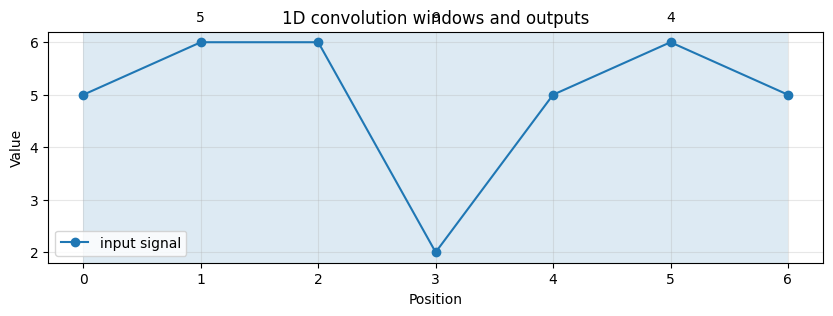

In [7]:

signal = np.array([5, 6, 6, 2, 5, 6, 5])
kernel = np.array([1, -1, 1])
stride = 2

positions = list(range(0, len(signal) - len(kernel) + 1, stride))
values = [np.sum(signal[p:p+len(kernel)] * kernel) for p in positions]

plt.figure(figsize=(10, 3))
plt.plot(signal, marker="o", label="input signal")
for p, v in zip(positions, values):
    plt.axvspan(p, p + len(kernel) - 1, alpha=0.15)
    plt.text(p + 1, max(signal) + 0.4, f"{v:.0f}", ha="center")
plt.title("1D convolution windows and outputs")
plt.xlabel("Position")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 5. 2D convolution on an image-like array

Now we move to a tiny grayscale image represented as a matrix.

We define:
- a **vertical edge detector**
- a **horizontal edge detector**

This is the key CNN intuition: early layers detect local patterns such as edges.


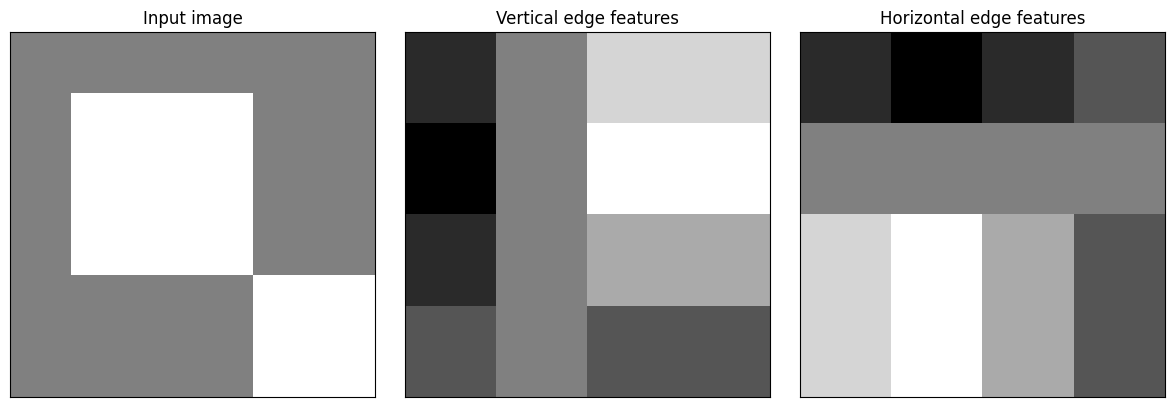

In [8]:

image = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 1, 1],
], dtype=float)

vertical_kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
], dtype=float)

horizontal_kernel = np.array([
    [1,  1,  1],
    [0,  0,  0],
    [-1, -1, -1]
], dtype=float)

def conv2d_valid(img, kernel, stride=1):
    img = np.asarray(img)
    kernel = np.asarray(kernel)
    kh, kw = kernel.shape
    out_h = (img.shape[0] - kh) // stride + 1
    out_w = (img.shape[1] - kw) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = img[i*stride:i*stride+kh, j*stride:j*stride+kw]
            out[i, j] = np.sum(region * kernel)
    return out

vertical_features = conv2d_valid(image, vertical_kernel)
horizontal_features = conv2d_valid(image, horizontal_kernel)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image, cmap="gray", vmin=-1, vmax=1)
axes[0].set_title("Input image")
axes[1].imshow(vertical_features, cmap="gray")
axes[1].set_title("Vertical edge features")
axes[2].imshow(horizontal_features, cmap="gray")
axes[2].set_title("Horizontal edge features")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()



## 6. ReLU after convolution

CNN layers usually apply a nonlinear activation such as ReLU after convolution.

This keeps only positive responses and introduces nonlinearity.


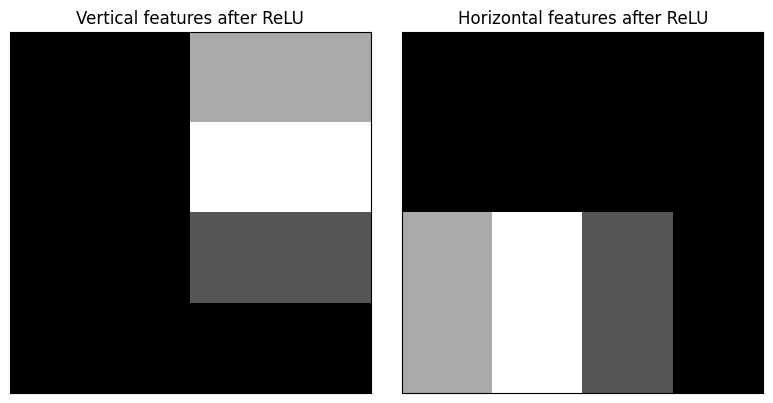

In [9]:

vertical_relu = relu(vertical_features)
horizontal_relu = relu(horizontal_features)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(vertical_relu, cmap="gray")
axes[0].set_title("Vertical features after ReLU")
axes[1].imshow(horizontal_relu, cmap="gray")
axes[1].set_title("Horizontal features after ReLU")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()



## 7. Pooling demonstration

Pooling summarizes local neighborhoods.

We implement:
- **max pooling**
- **average pooling**


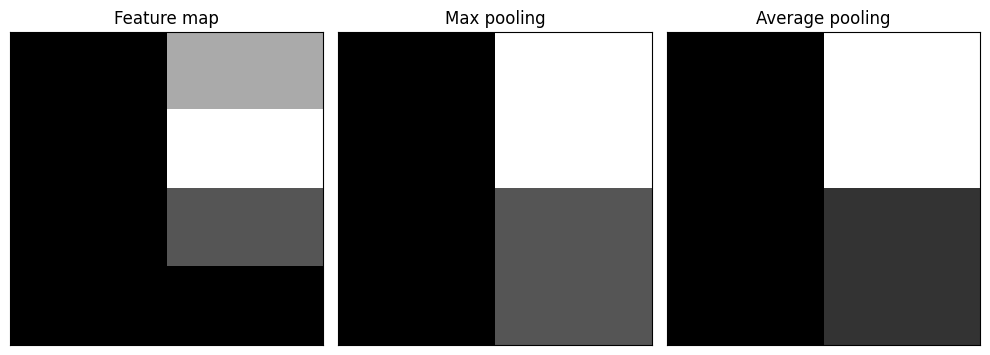

In [10]:

def max_pool2d(img, size=2, stride=2):
    h, w = img.shape
    out_h = (h - size) // stride + 1
    out_w = (w - size) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = img[i*stride:i*stride+size, j*stride:j*stride+size]
            out[i, j] = np.max(region)
    return out

def avg_pool2d(img, size=2, stride=2):
    h, w = img.shape
    out_h = (h - size) // stride + 1
    out_w = (w - size) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = img[i*stride:i*stride+size, j*stride:j*stride+size]
            out[i, j] = np.mean(region)
    return out

pooled_max = max_pool2d(vertical_relu, size=2, stride=2)
pooled_avg = avg_pool2d(vertical_relu, size=2, stride=2)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(vertical_relu, cmap="gray")
axes[0].set_title("Feature map")
axes[1].imshow(pooled_max, cmap="gray")
axes[1].set_title("Max pooling")
axes[2].imshow(pooled_avg, cmap="gray")
axes[2].set_title("Average pooling")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()



## 8. A tiny CNN-style pipeline

This is not a trainable deep learning framework. It is a didactic pipeline showing the flow:

1. image input  
2. convolution with two kernels  
3. ReLU  
4. pooling  
5. flatten  
6. small dense layer for binary classification

We will use two hand-crafted image classes:
- vertical bar
- horizontal bar


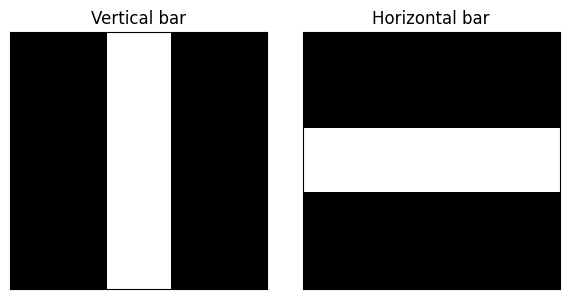

In [11]:

def make_vertical_bar(size=8):
    img = np.zeros((size, size))
    img[:, size//2 - 1:size//2 + 1] = 1.0
    return img

def make_horizontal_bar(size=8):
    img = np.zeros((size, size))
    img[size//2 - 1:size//2 + 1, :] = 1.0
    return img

vertical_img = make_vertical_bar()
horizontal_img = make_horizontal_bar()

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(vertical_img, cmap="gray")
axes[0].set_title("Vertical bar")
axes[1].imshow(horizontal_img, cmap="gray")
axes[1].set_title("Horizontal bar")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()


In [12]:

# Kernels
k_vertical = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
], dtype=float)

k_horizontal = np.array([
    [1,  1,  1],
    [0,  0,  0],
    [-1, -1, -1]
], dtype=float)

def cnn_features(img):
    f1 = relu(conv2d_valid(img, k_vertical))
    f2 = relu(conv2d_valid(img, k_horizontal))
    p1 = max_pool2d(f1, size=2, stride=2)
    p2 = max_pool2d(f2, size=2, stride=2)
    return np.concatenate([p1.ravel(), p2.ravel()])

fv = cnn_features(vertical_img)
fh = cnn_features(horizontal_img)

print("Feature vector length:", len(fv))
print("\nVertical image features:")
print(fv)
print("\nHorizontal image features:")
print(fh)


Feature vector length: 18

Vertical image features:
[0. 3. 3. 0. 3. 3. 0. 3. 3. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Horizontal image features:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 3. 3. 3. 3. 3. 3.]


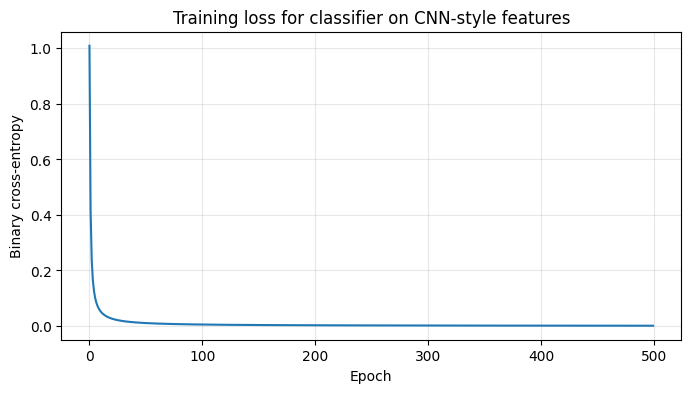

Test accuracy: 1.0


In [13]:

# Build a small dataset with noise
def add_noise(img, noise_level=0.15):
    noisy = img + rng.normal(0, noise_level, img.shape)
    return np.clip(noisy, 0, 1)

X_features = []
y_labels = []

for _ in range(60):
    X_features.append(cnn_features(add_noise(make_vertical_bar())))
    y_labels.append(1)
    X_features.append(cnn_features(add_noise(make_horizontal_bar())))
    y_labels.append(0)

X_features = np.array(X_features)
y_labels = np.array(y_labels).reshape(-1, 1)

# Train/test split
indices = rng.permutation(len(X_features))
split = int(0.8 * len(indices))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X_features[train_idx], X_features[test_idx]
y_train, y_test = y_labels[train_idx], y_labels[test_idx]

# Dense classifier: logistic regression on top of CNN features
W = rng.normal(0, 0.1, size=(X_train.shape[1], 1))
b = np.zeros((1, 1))

lr = 0.1
epochs = 500
history = []

for epoch in range(epochs):
    logits = X_train @ W + b
    preds = sigmoid(logits)

    # Binary cross-entropy
    eps = 1e-8
    loss = -np.mean(y_train * np.log(preds + eps) + (1 - y_train) * np.log(1 - preds + eps))
    history.append(loss)

    # Gradients
    dlogits = (preds - y_train) / len(X_train)
    dW = X_train.T @ dlogits
    db = np.sum(dlogits, axis=0, keepdims=True)

    W -= lr * dW
    b -= lr * db

plt.figure(figsize=(8, 4))
plt.plot(history)
plt.title("Training loss for classifier on CNN-style features")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.grid(True, alpha=0.3)
plt.show()

test_probs = sigmoid(X_test @ W + b)
test_preds = (test_probs > 0.5).astype(int)
accuracy = np.mean(test_preds == y_test)

print("Test accuracy:", accuracy)



## 9. Visualizing intermediate feature maps for one example

This is often the most useful CNN teaching cell: students can see that the network is not magic. It is transforming the image step by step.


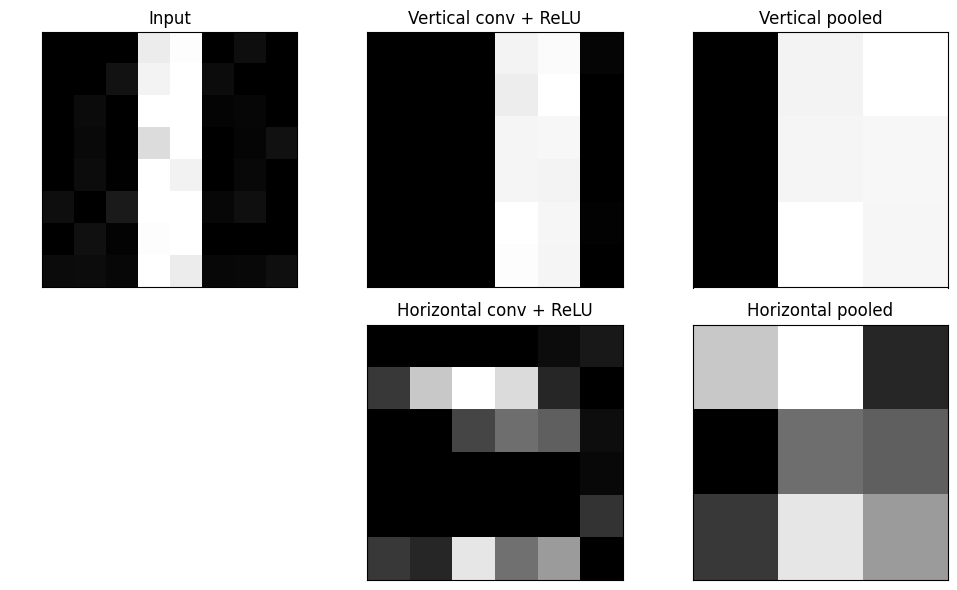

In [14]:

example = add_noise(make_vertical_bar(), noise_level=0.05)

f1 = relu(conv2d_valid(example, k_vertical))
f2 = relu(conv2d_valid(example, k_horizontal))
p1 = max_pool2d(f1, size=2, stride=2)
p2 = max_pool2d(f2, size=2, stride=2)

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes[0, 0].imshow(example, cmap="gray")
axes[0, 0].set_title("Input")
axes[0, 1].imshow(f1, cmap="gray")
axes[0, 1].set_title("Vertical conv + ReLU")
axes[0, 2].imshow(p1, cmap="gray")
axes[0, 2].set_title("Vertical pooled")

axes[1, 0].axis("off")
axes[1, 1].imshow(f2, cmap="gray")
axes[1, 1].set_title("Horizontal conv + ReLU")
axes[1, 2].imshow(p2, cmap="gray")
axes[1, 2].set_title("Horizontal pooled")

for row in axes:
    for ax in row:
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()



## 10. Suggested teaching discussion

Questions for students:
1. Why can the XOR problem not be solved by a single linear layer?
2. In the backprop example, what role does the chain rule play?
3. Why does convolution drastically reduce parameter count compared to full connectivity?
4. Why is max pooling often interpreted as feature presence detection?
5. Why do deeper layers usually detect more abstract patterns?

## Summary

This notebook demonstrated:
- **manual backpropagation** in a small feedforward network
- **convolution** as sliding local pattern detectors
- **ReLU and pooling**
- a **CNN-style feature extraction pipeline**

For lecture use, this is enough to make the mechanics concrete without hiding everything behind a large framework.
